## Crypto Market Exploratory Data Analysis

In this exploratory data analysis (EDA), we will analyze the cryptocurrency market using a dataset that contains historical price data for various cryptocurrencies. The goal of this analysis is to uncover insights about the market trends, price movements, and potential correlations between different cryptocurrencies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
# Load data from SQLite database
conn = sqlite3.connect('../data/crypto_market_data.db')

query = """
    SELECT * 
    FROM crypto_market_data
"""
df = pd.read_sql(query, conn)
conn.close()
df.head()

,coin_id,symbol,name,current_price,market_cap,volume_24h,price_change_percentage_24h,date,last_updated
0,bitcoin,BTC,Bitcoin,"65,572.00","1,311,092,974,135.00","38,848,033,221.00",-3.17,2026-02-28,2026-02-28 07:04:08.686551
1,ethereum,ETH,Ethereum,"1,919.53","231,657,713,693.00","18,536,773,997.00",-5.98,2026-02-28,2026-02-28 07:04:08.686551
2,tether,USDT,Tether,1.00,"183,573,094,989.00","64,480,642,082.00",-0.01,2026-02-28,2026-02-28 07:04:08.686551
3,binancecoin,BNB,BNB,610.90,"83,296,532,607.00","1,025,190,742.00",-3.23,2026-02-28,2026-02-28 07:04:08.686551
4,ripple,XRP,XRP,1.35,"82,430,698,889.00","2,886,032,006.00",-4.31,2026-02-28,2026-02-28 07:04:08.686551


In [3]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [4]:
# Check for missing values
df.isnull().sum()

coin_id                        0
symbol                         0
name                           0
current_price                  0
market_cap                     0
volume_24h                     0
price_change_percentage_24h    0
date                           0
last_updated                   0
dtype: int64

In [ ]:
# Summary statistics
df['current_price'].describe()

count      100.00
mean       806.27
std      6,586.95
min          0.00
25%          0.16
50%          1.00
75%          4.52
max     65,572.00
Name: current_price, dtype: float64

<Axes: >

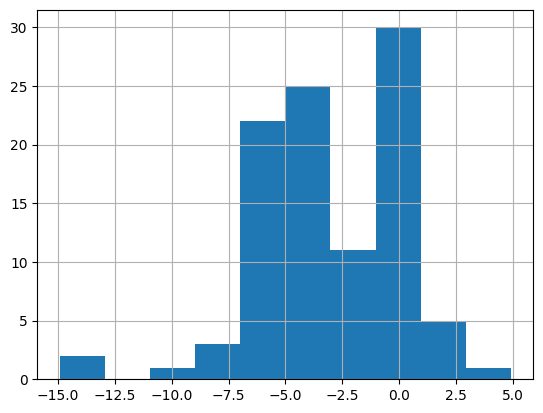

In [ ]:
# Distribution of price change
df['price_change_percentage_24h'].hist()

In [7]:
# Total market cap
total_market_cap = df['market_cap'].sum()
f"{int(total_market_cap):,}"

'2,282,274,689,174'

In [8]:
# Top 10 cryptocurrencies by market cap
top_10 = df.nlargest(10, 'market_cap')[['name', 'symbol', 'market_cap']].reset_index(drop=True)
top_10


,name,symbol,market_cap
0,Bitcoin,BTC,"1,311,092,974,135.00"
1,Ethereum,ETH,"231,657,713,693.00"
2,Tether,USDT,"183,573,094,989.00"
3,BNB,BNB,"83,296,532,607.00"
4,XRP,XRP,"82,430,698,889.00"
5,USDC,USDC,"75,202,731,721.00"
6,Solana,SOL,"46,425,266,025.00"
7,TRON,TRX,"26,775,936,879.00"
8,Figure Heloc,FIGR_HELOC,"16,189,083,806.00"
9,Dogecoin,DOGE,"15,633,825,428.00"


In [9]:
# Market cap percentage and dominance
market_cap_percentage = df['market_cap'] / df['market_cap'].sum() * 100
market_cap_percentage.head(10)
 

0   57.45
1   10.15
2    8.04
3    3.65
4    3.61
5    3.30
6    2.03
7    1.17
8    0.71
9    0.69
Name: market_cap, dtype: float64

In [10]:
# Trade volume per market cap
df['liquidity_ratio'] = df['volume_24h'] / df['market_cap']
df[['name', 'liquidity_ratio']].head(10)

,name,liquidity_ratio
0,Bitcoin,0.03
1,Ethereum,0.08
2,Tether,0.35
3,BNB,0.01
4,XRP,0.04
5,USDC,0.05
6,Solana,0.08
7,TRON,0.02
8,Figure Heloc,0.01
9,Dogecoin,0.06


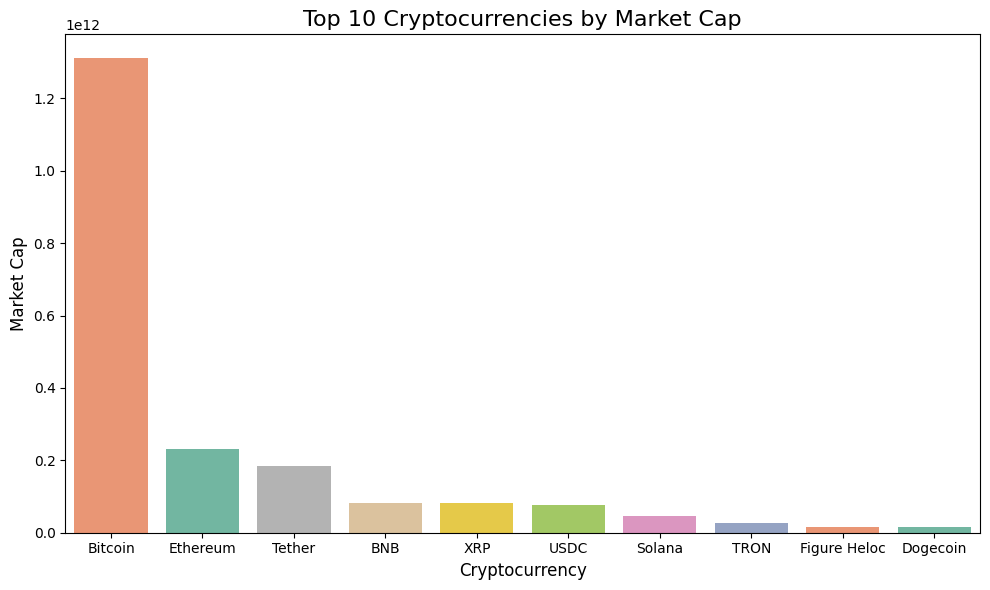

In [11]:
# Visualize top 10 cryptocurrencies by market cap
plt.figure(figsize=(10, 6))
sns.barplot(x='name', y='market_cap', data=top_10, palette='Set2', hue='market_cap', legend=False)
plt.title('Top 10 Cryptocurrencies by Market Cap', fontsize=16)
plt.xlabel('Cryptocurrency', fontsize=12)
plt.ylabel('Market Cap', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/top_10_market_cap.png')
plt.show()

In [12]:
# Total trade volume
total_volume = df['volume_24h'].sum()
f"{int(total_volume):,}"

'144,550,143,606'

In [13]:
# Top 10 cryptocurrencies by 24h trading volume
top_10_volume = df.nlargest(10, 'volume_24h')[['name', 'symbol', 'volume_24h']].reset_index(drop=True)
top_10_volume

,name,symbol,volume_24h
0,Tether,USDT,"64,480,642,082.00"
1,Bitcoin,BTC,"38,848,033,221.00"
2,Ethereum,ETH,"18,536,773,997.00"
3,USDC,USDC,"3,793,070,900.00"
4,Solana,SOL,"3,753,237,287.00"
5,XRP,XRP,"2,886,032,006.00"
6,USD1,USD1,"1,630,886,861.00"
7,BNB,BNB,"1,025,190,742.00"
8,Dogecoin,DOGE,"916,094,342.00"
9,Sui,SUI,"656,883,872.00"


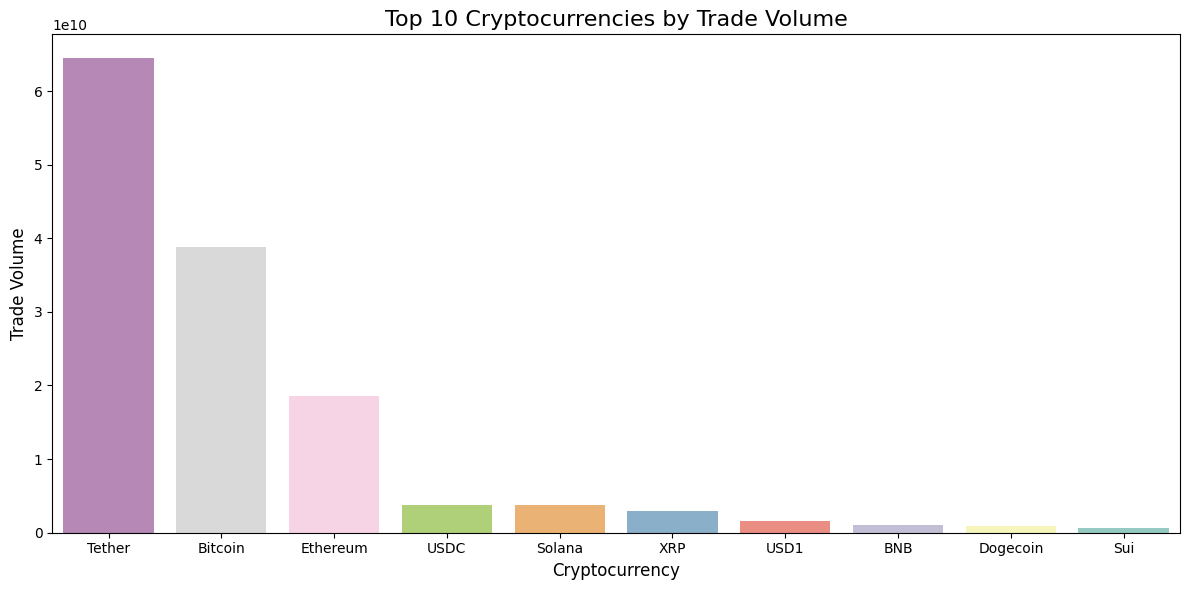

In [14]:
# Visualize top 10 cryptocurrencies by Trade volume
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='volume_24h', data=top_10_volume, palette='Set3', hue='volume_24h', legend=False)
plt.title('Top 10 Cryptocurrencies by Trade Volume', fontsize=16)
plt.xlabel('Cryptocurrency', fontsize=12)
plt.ylabel('Trade Volume', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/top_10_volume.png')
plt.show()

In [15]:
# Average 24h price change
average_price_change = df['price_change_percentage_24h'].mean()
f"{average_price_change:.2f}"


'-3.04'

In [16]:
# Top 10 cryptocurrencies by gains
top_10_price_change = df.nlargest(10, 'price_change_percentage_24h')[['name', 'symbol', 'price_change_percentage_24h']].reset_index(drop=True)
top_10_price_change

,name,symbol,price_change_percentage_24h
0,Provenance Blockchain,HASH,4.91
1,Figure Heloc,FIGR_HELOC,2.66
2,PAX Gold,PAXG,2.12
3,Tether Gold,XAUT,2.04
4,Pi Network,PI,1.94
5,Beldex,BDX,0.99
6,LEO Token,LEO,0.42
7,Usual USD,USD0,0.17
8,Fasttoken,FTN,0.11
9,Ondo US Dollar Yield,USDY,0.10


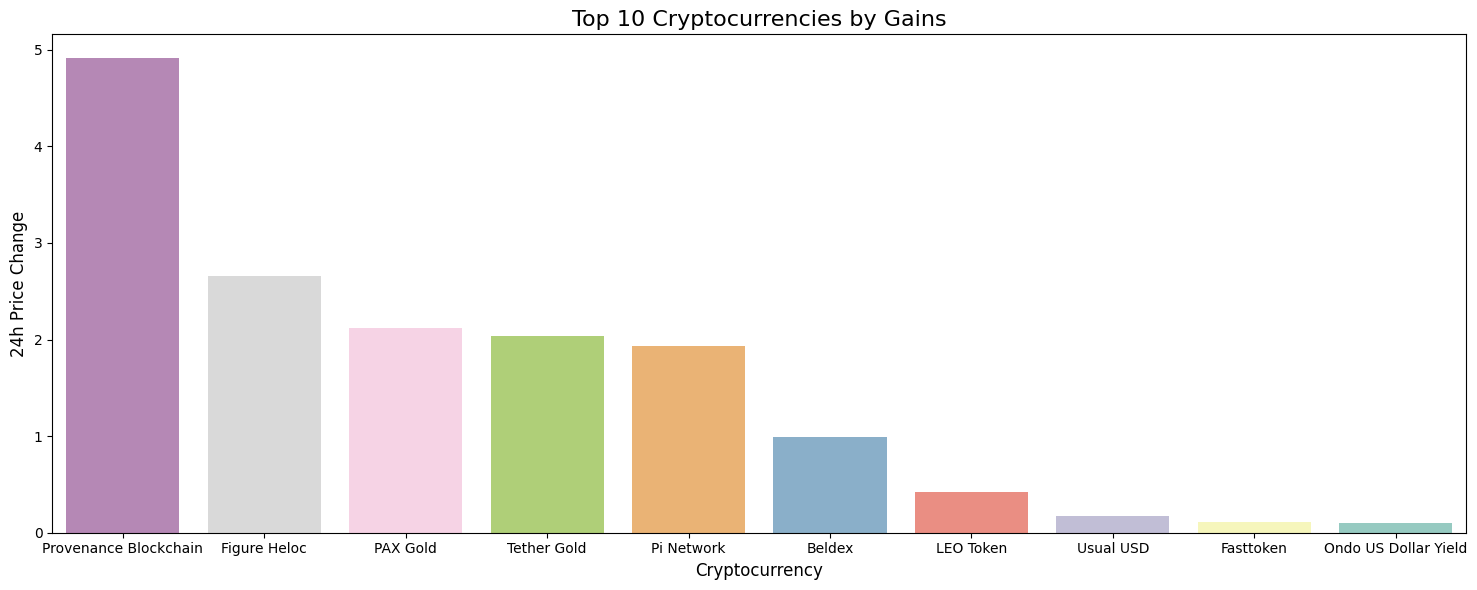

In [17]:
# Visualize top 10 cryptocurrencies by Gains
plt.figure(figsize=(15, 6))
sns.barplot(x='name', y='price_change_percentage_24h', data=top_10_price_change, palette='Set3', hue='price_change_percentage_24h', legend=False)
plt.title('Top 10 Cryptocurrencies by Gains', fontsize=16)
plt.xlabel('Cryptocurrency', fontsize=12)
plt.ylabel('24h Price Change', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/top_10_gains.png')
plt.show()

In [18]:
biggest_losers = df.nsmallest(10, 'price_change_percentage_24h')[['name', 'symbol', 'price_change_percentage_24h']].reset_index(drop=True)
biggest_losers

,name,symbol,price_change_percentage_24h
0,​​Stable,STABLE,-14.92
1,pippin,PIPPIN,-13.90
2,Zcash,ZEC,-9.21
3,Internet Computer,ICP,-7.97
4,Hyperliquid,HYPE,-7.59
5,Aptos,APT,-7.36
6,Sui,SUI,-6.86
7,Solana,SOL,-6.86
8,POL (ex-MATIC),POL,-6.73
9,Cardano,ADA,-6.62


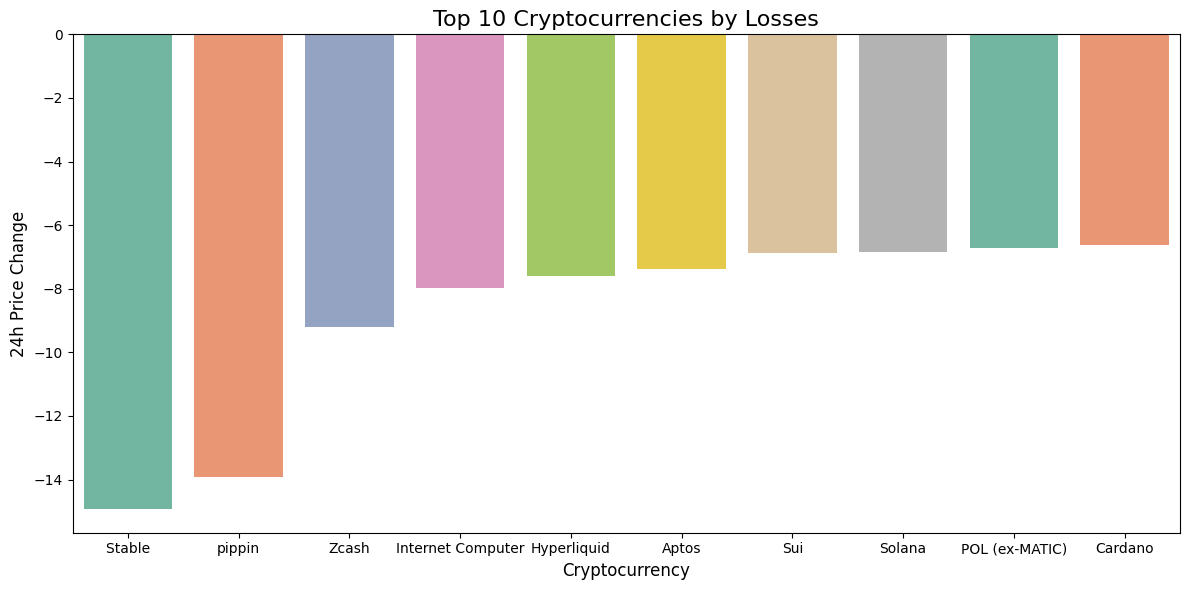

In [19]:
# Visualize top 10 cryptocurrencies by losses
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='price_change_percentage_24h', data=biggest_losers, palette='Set2', hue='price_change_percentage_24h', legend=False)
plt.title('Top 10 Cryptocurrencies by Losses', fontsize=16)
plt.xlabel('Cryptocurrency', fontsize=12)
plt.ylabel('24h Price Change', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/top_10_losses.png')
plt.show()

In [20]:
df[['current_price', 'market_cap', 'volume_24h']].corr()

,current_price,market_cap,volume_24h
current_price,1.00,0.97,0.49
market_cap,0.97,1.00,0.63
volume_24h,0.49,0.63,1.00


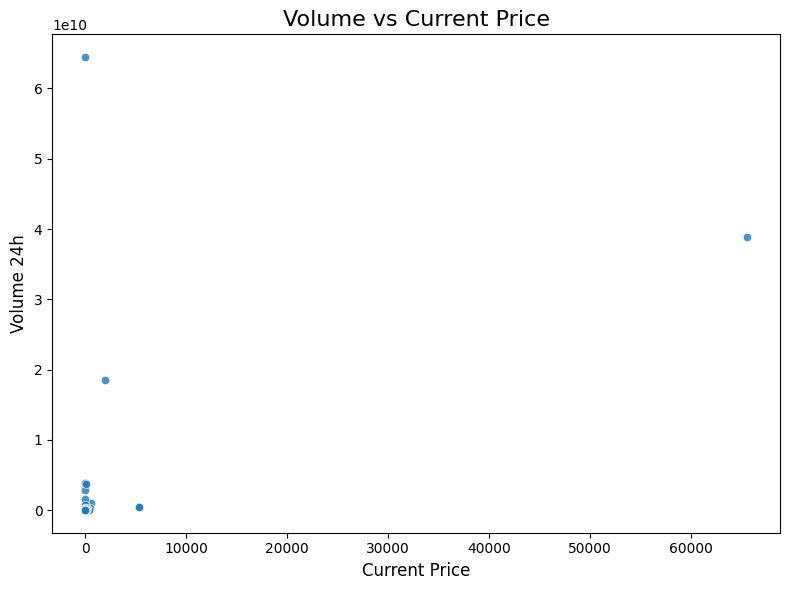

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='current_price', y='volume_24h', data=df, alpha=0.8, legend=False)
plt.title('Volume vs Current Price', fontsize=16)
plt.xlabel('Current Price', fontsize=12)
plt.ylabel('Volume 24h', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/volume_vs_current_price.png')
plt.show()
